In [1]:
from matplotlib.pyplot import *
import matplotlib.font_manager as fm

rcParams['mathtext.rm'] = "Arial"
rcParams['font.family'] = 'Arial'
for f in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if 'arial' in f.lower():
        print(f)

C:\Windows\Fonts\ARIALNI.TTF
C:\Windows\Fonts\arialbd.ttf
C:\Windows\Fonts\arialbi.ttf
C:\Windows\Fonts\ARIALNBI.TTF
C:\Windows\Fonts\ariali.ttf
C:\Windows\Fonts\arial.ttf
C:\Windows\Fonts\ARIALN.TTF
C:\Windows\Fonts\ARIALNB.TTF


In [2]:
from select_points import load_data
path1 = "training_data/for_model1.csv"
path2 = "training_data/for_model2.csv"
X1, Y1 = load_data(path1)
X2, Y2 = load_data(path2)

In [3]:
from train_evaluation import normalize_data, train_LSmodels, train_RFmodels
norm_X1 = normalize_data(X1)
norm_X2 = normalize_data(X2)
LS_model1, all_LSperformance1 = train_LSmodels(norm_X1, Y1)
LS_model2, all_LSperformance2 = train_LSmodels(norm_X2, Y2)
RF_model1, all_RFperformance1, feature_importance1 = train_RFmodels(norm_X1, Y1)
RF_model2, all_RFperformance2, feature_importance2= train_RFmodels(norm_X2, Y2)

Training LabelSpreading with random_state=42
Training LabelSpreading with random_state=43
Training LabelSpreading with random_state=44
Training LabelSpreading with random_state=45
Training LabelSpreading with random_state=46
Training LabelSpreading with random_state=47
Training LabelSpreading with random_state=48
Training LabelSpreading with random_state=49
Training LabelSpreading with random_state=50
Training LabelSpreading with random_state=51
Training LabelSpreading with random_state=52
Training LabelSpreading with random_state=53
Training LabelSpreading with random_state=54
Training LabelSpreading with random_state=55
Training LabelSpreading with random_state=56
Training LabelSpreading with random_state=57
最佳模型验证集准确率: 0.7708
Training LabelSpreading with random_state=42
Training LabelSpreading with random_state=43
Training LabelSpreading with random_state=44
Training LabelSpreading with random_state=45
Training LabelSpreading with random_state=46
Training LabelSpreading with random_

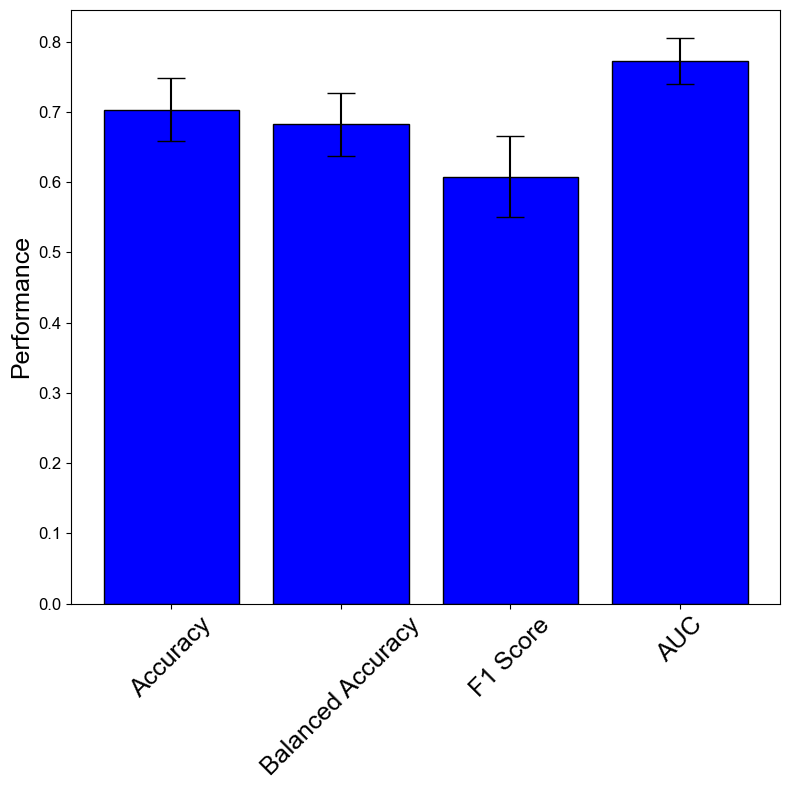

[0.703125   0.68242587 0.60771442 0.77205107]
[0.04486428 0.04507051 0.0572896  0.03278045]


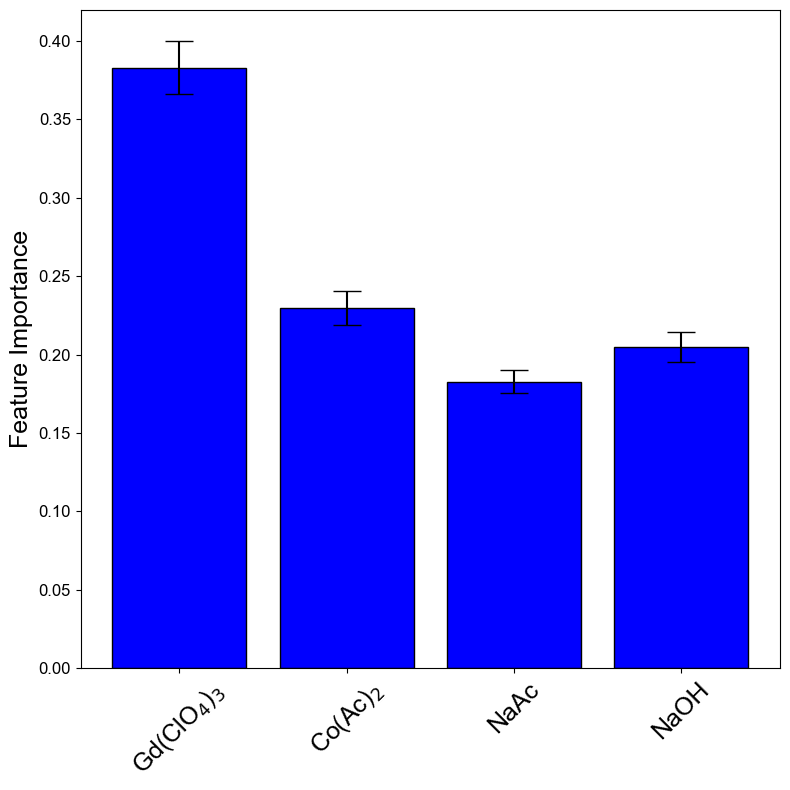

[0.38277901 0.22965463 0.18277607 0.20479029]
[0.01693454 0.0105982  0.00744233 0.00972654]


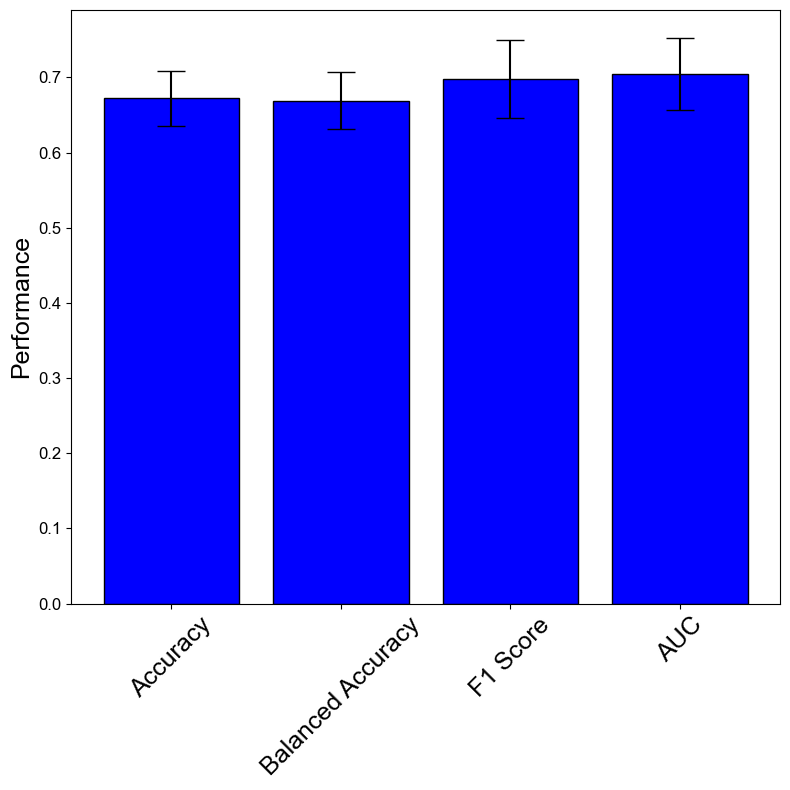

[0.671875   0.66890145 0.69754345 0.70401894]
[0.03719494 0.03794624 0.05210753 0.0479514 ]


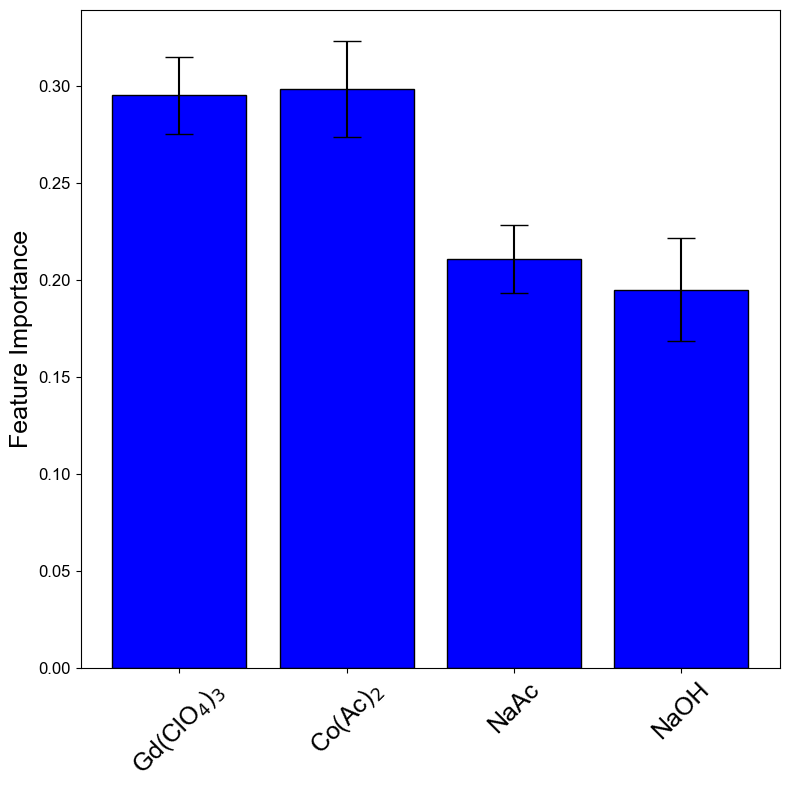

[0.2952527  0.29853524 0.21098389 0.19522818]
[0.01964629 0.02462572 0.01774925 0.0267497 ]


(array([0.2952527 , 0.29853524, 0.21098389, 0.19522818]),
 array([0.01964629, 0.02462572, 0.01774925, 0.0267497 ]))

In [4]:
from plot_tools import plot_performance, plot_feature_importance
all_RFperformance1 = np.array(all_RFperformance1)
all_RFperformance2 = np.array(all_RFperformance2)
feature_names = [r'Gd(ClO$_4$)$_3$', r'Co(Ac)$_2$', "NaAc", "NaOH"]
plot_performance(all_RFperformance1)
plot_feature_importance(feature_importance1, feature_names)
plot_performance(all_RFperformance2)
plot_feature_importance(feature_importance2, feature_names)

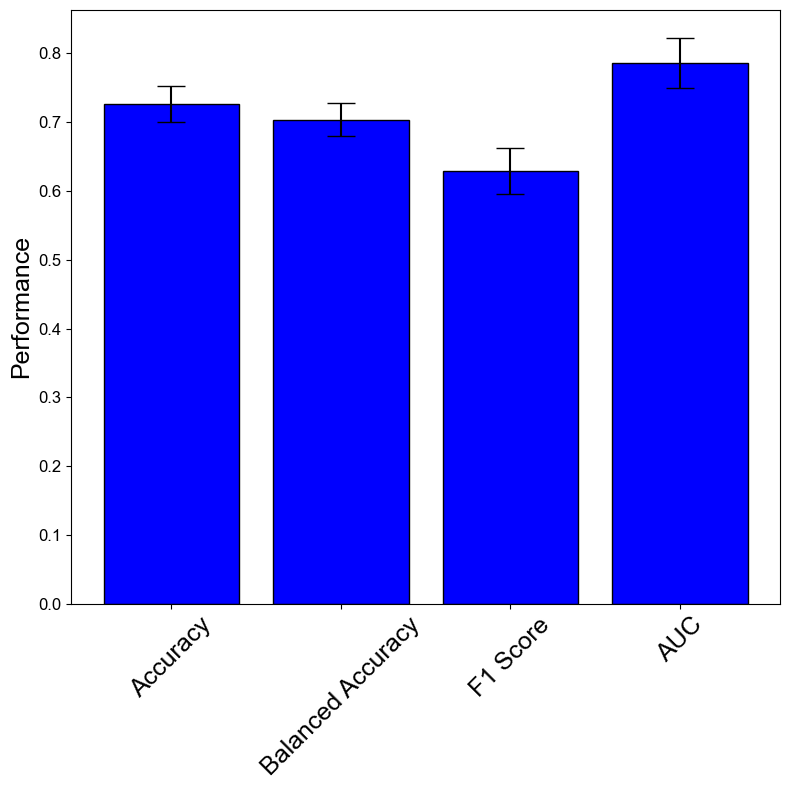

[0.7265625  0.70386588 0.62912408 0.78570019]
[0.02589018 0.0242943  0.03362802 0.0364199 ]


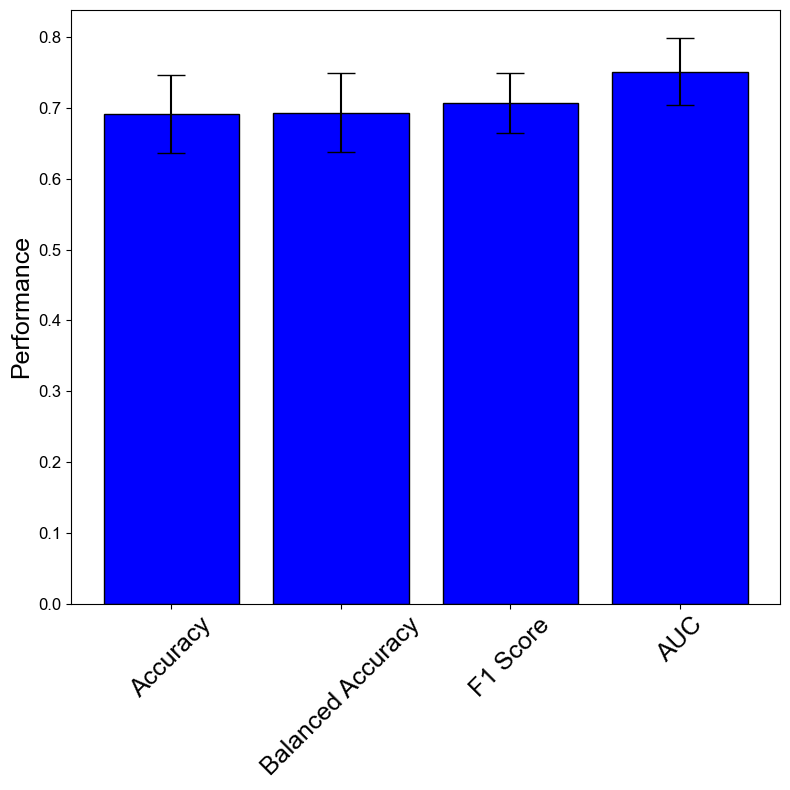

[0.69140625 0.69298908 0.7069843  0.75137553]
[0.05522737 0.05593959 0.04263953 0.04700278]


(array([0.69140625, 0.69298908, 0.7069843 , 0.75137553]),
 array([0.05522737, 0.05593959, 0.04263953, 0.04700278]))

In [5]:
from plot_tools import plot_performance
all_LSperformance1 = np.array(all_LSperformance1)
all_LSperformance2 = np.array(all_LSperformance2)
plot_performance(all_LSperformance1)
plot_performance(all_LSperformance2)

(<Figure size 2400x2400 with 2 Axes>,
 <Axes: xlabel='Gd(ClO$_4$)$_3$', ylabel='NaOH'>)

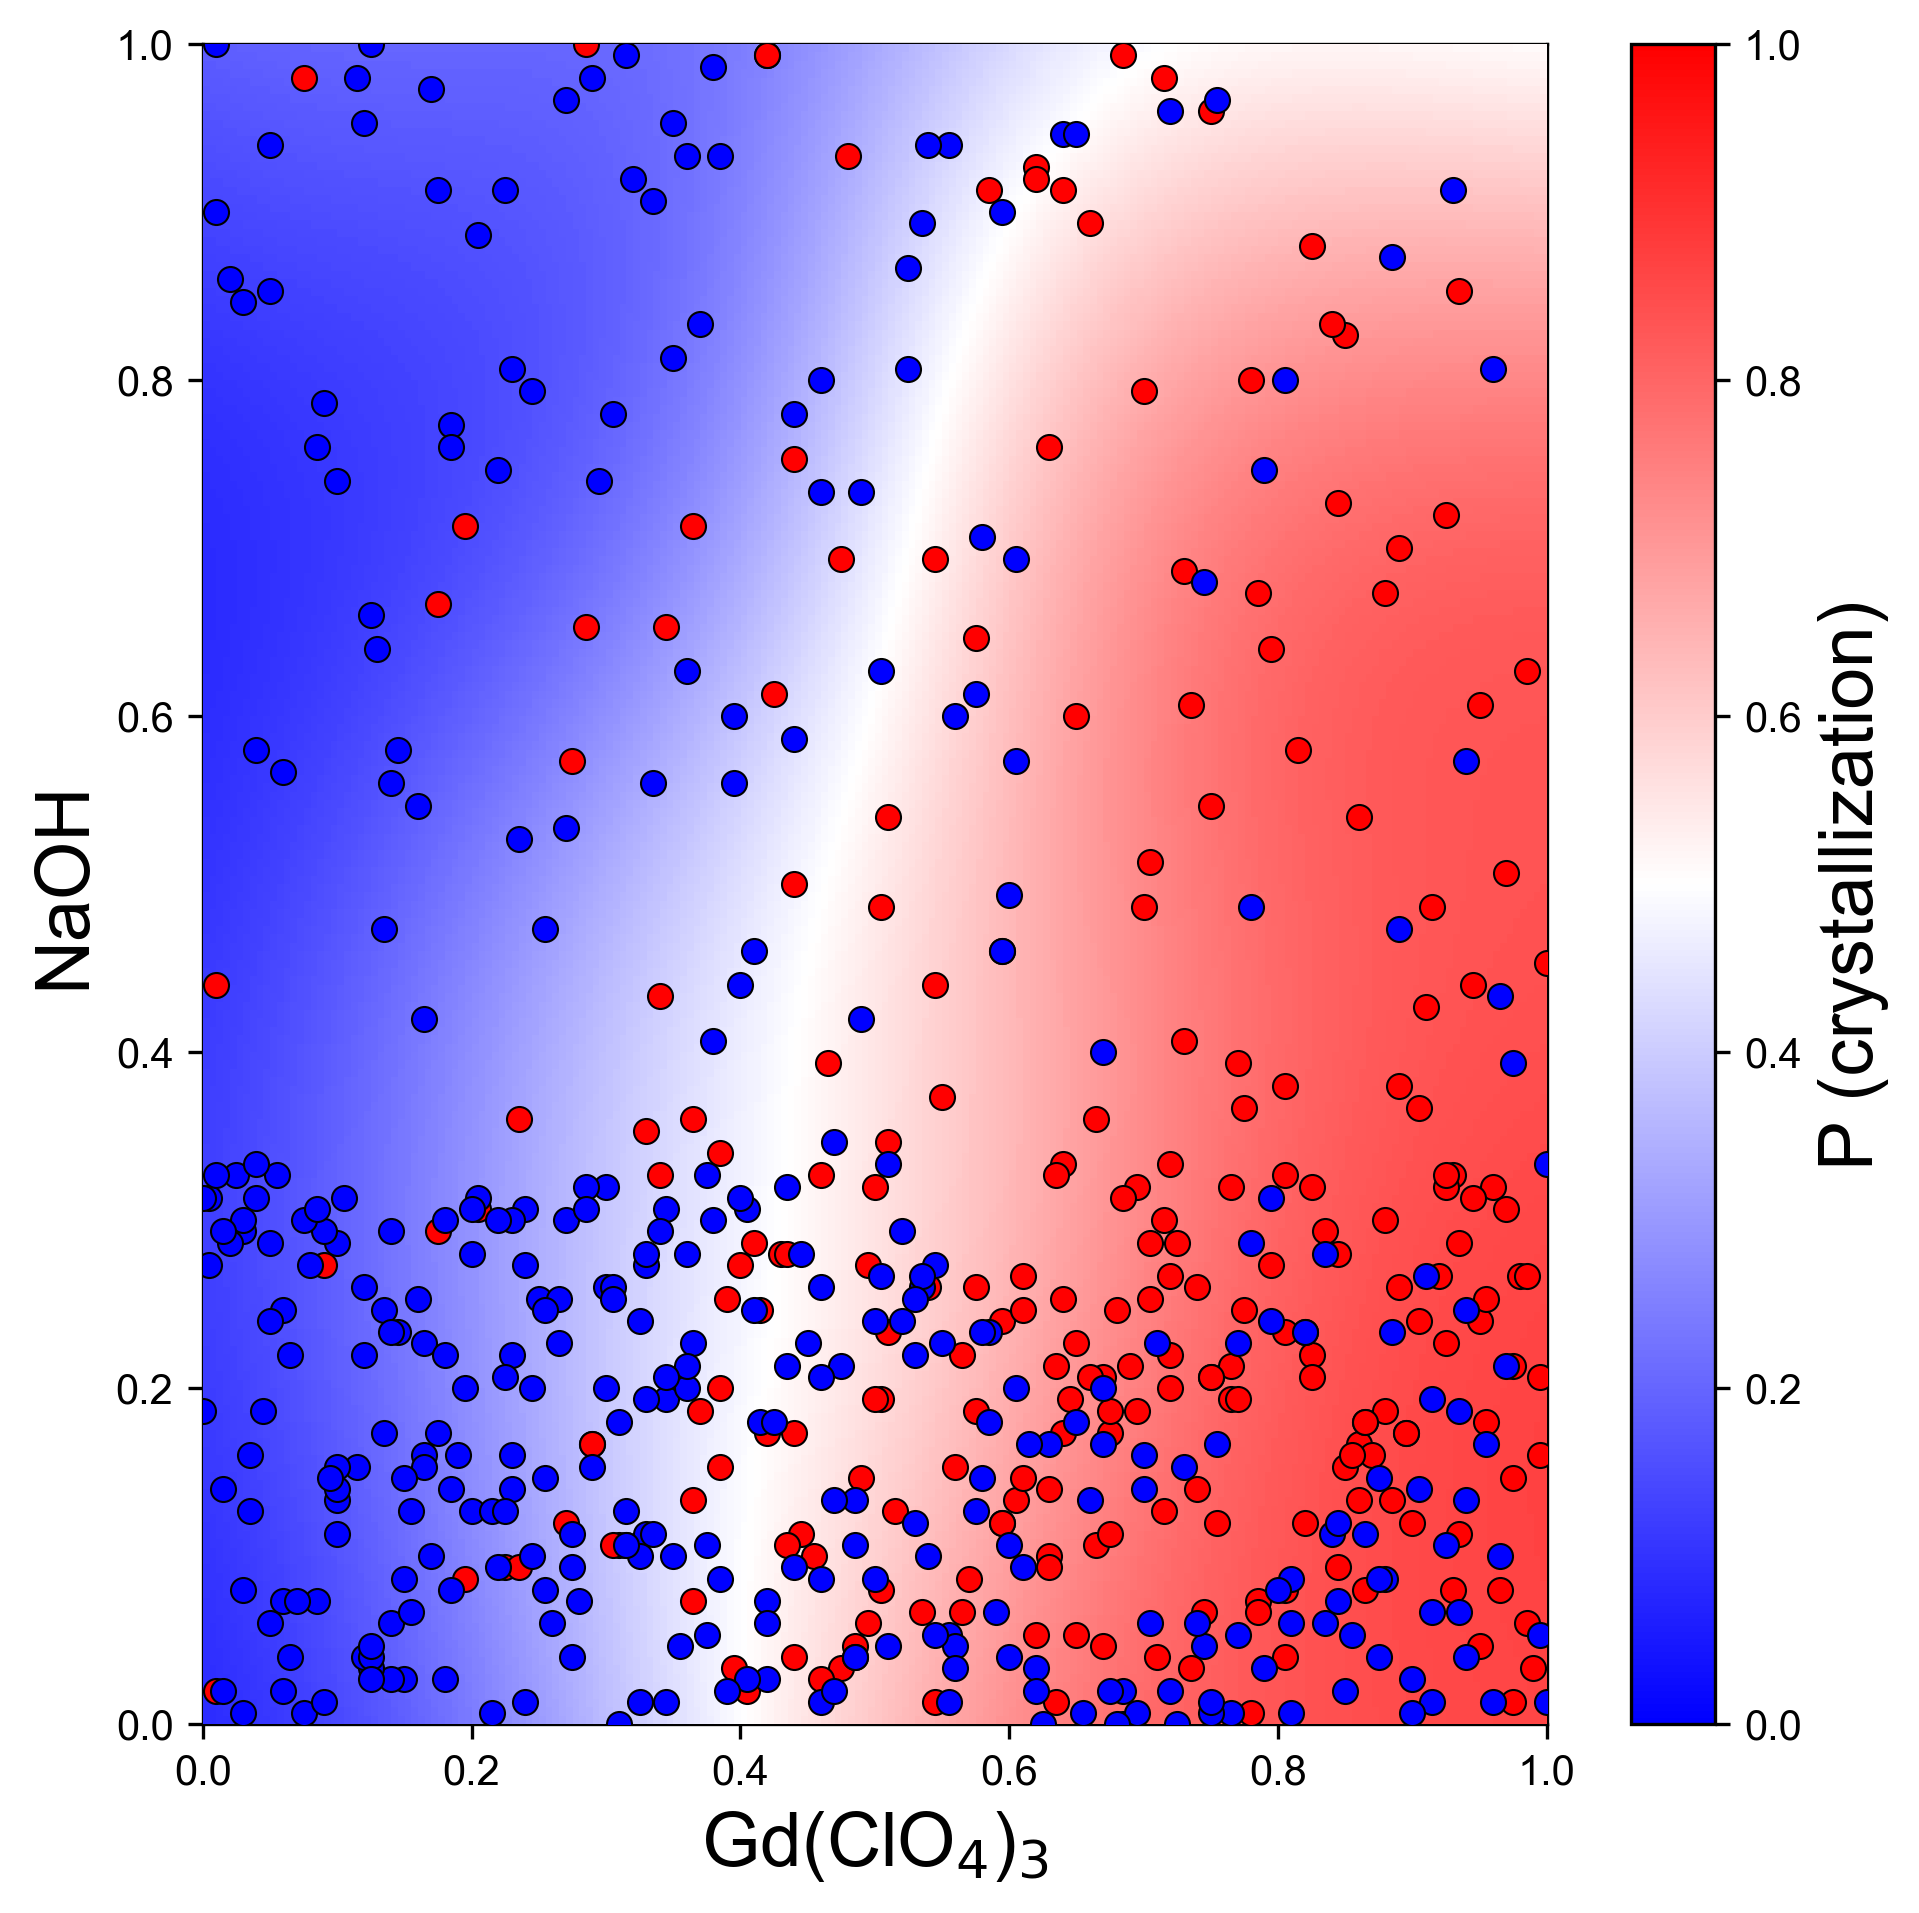

In [9]:
from plot_tools import plot_phase_diagram, create_prediction_grid
dimension_index = [0, 3]  # 选择要绘制的两个自由维度索引
X_grid, grid_shape = create_prediction_grid(
    fixed_dims=[1, 2], #选择固定的特征索引
    fixed_vals=[0.5, 0.5], #固定特征的值（选定切片位置）
    resolution=200  # 200^2 = 40000个点
)
feature_names = [r'Gd(ClO$_4$)$_3$', r'Co(Ac)$_2$', "NaAc", "NaOH"]
#做切片
plot_phase_diagram(LS_model1, X_grid, grid_shape, norm_X1, Y1, dimension_index, feature_names)


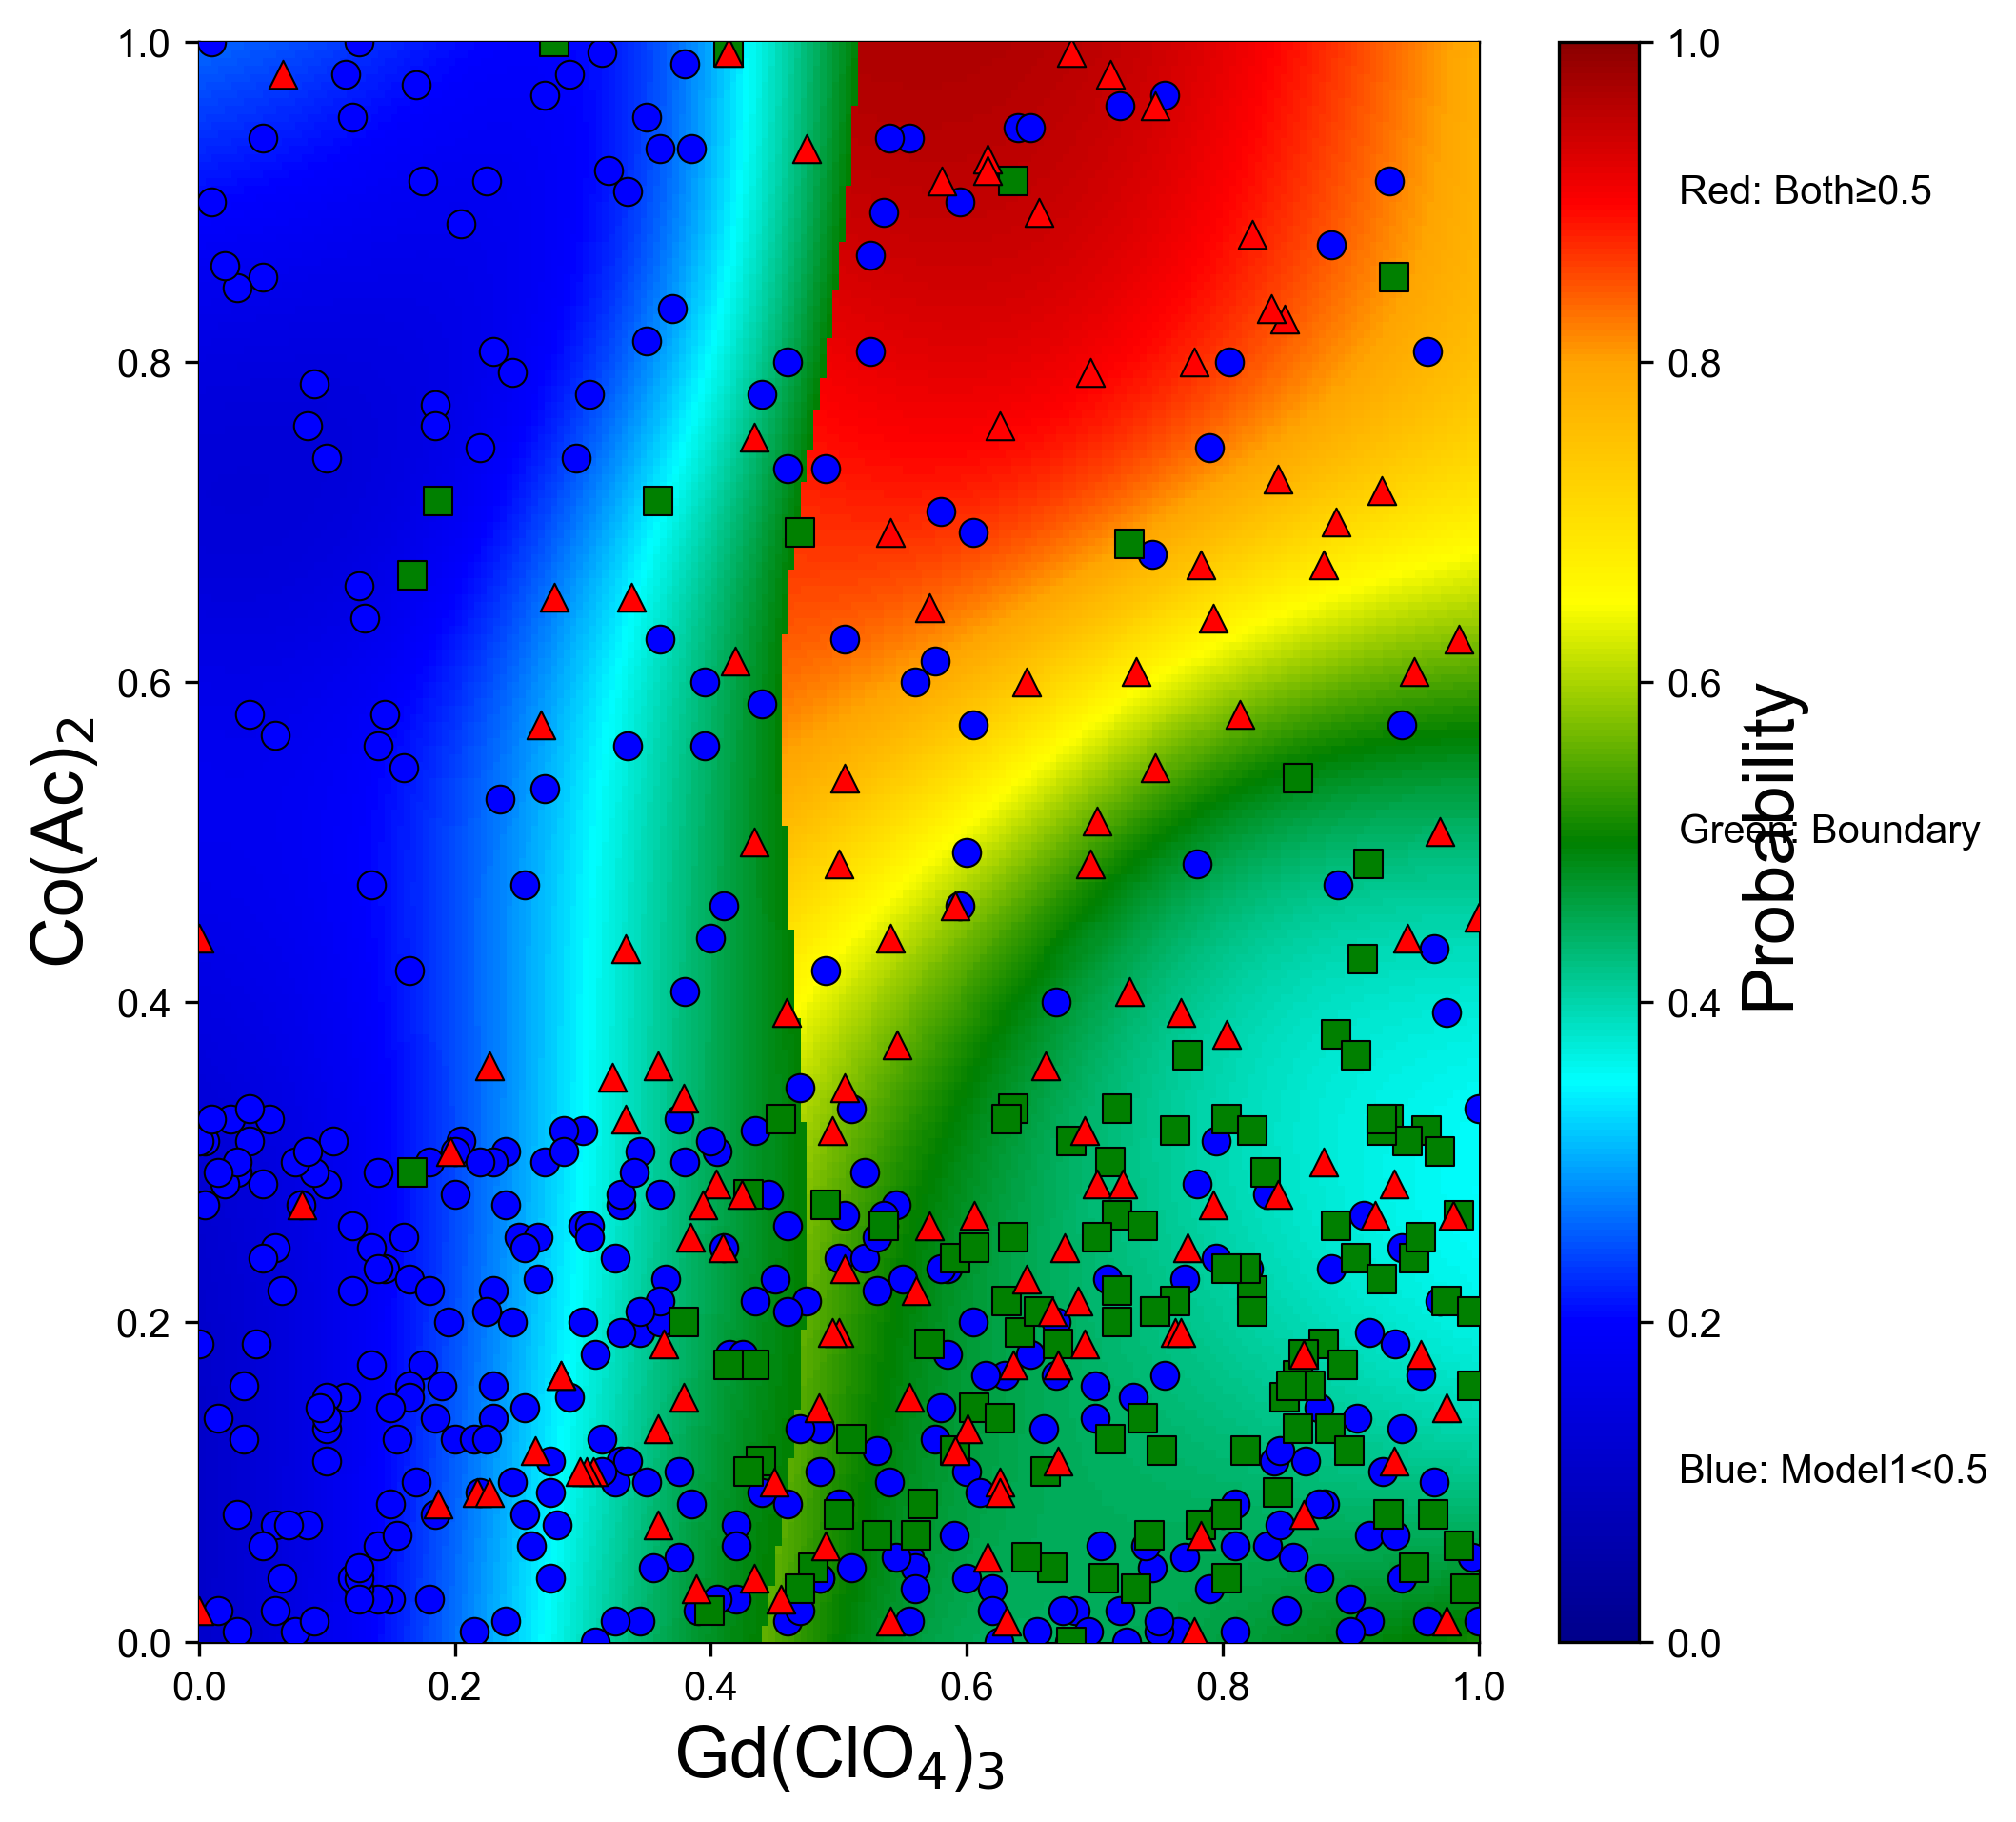

In [12]:
from plot_tools import plot_phase_diagram_cascade, create_prediction_grid
dimension_index = [0, 1]  # 选择要绘制的两个自由维度索引
X_grid, grid_shape = create_prediction_grid(
    fixed_dims=[2, 3], #选择固定的特征索引
    fixed_vals=[0.25, 0.25], #固定特征的值（选定切片位置）
    resolution=200  # 200^2 = 40000个点
)
feature_names = [r'Gd(ClO$_4$)$_3$', r'Co(Ac)$_2$', "NaAc", "NaOH"]
plot_phase_diagram_cascade(LS_model1, LS_model2, X_grid, grid_shape, norm_X1, Y1, norm_X2, Y2, dimension_index, feature_names)